# Digit Recognition

In this tutorial you will implement a image classifier to recognize handwritten digits.
To start simple the task is a $d$-dimensional linear regression task.
We have already implemented the dataset and an MLP, but you will have to implement the training loop yourself!

### Credits
Bryan Chan, Nov. 2024  

In [15]:
%matplotlib inline
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision

from typing import List

device = "cpu"

### Construct a convolutional network, LeNet
Here you have to implement LeNet-5, which was proposed LeCun et al. (1995).
Please use `ReLU` activation after pooling layers, and after linear layers.
Below are two different diagrams representing LeNet-5.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/3/35/LeNet-5_architecture.svg/2560px-LeNet-5_architecture.svg.png" style="background-color:white; width: 80%;" />
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/5e/LeNet-5_architecture_block_diagram.svg/800px-LeNet-5_architecture_block_diagram.svg.png" style="background-color:white; width: 15%;" />

Since then we have made great advancements, e.g. ResNets, U-Nets, Vision Transformers, etc., but convolutional layers are still very relevant for any vision tasks!

In [16]:
class LeNet(torch.nn.Module):
    def __init__(
        self,
        in_channels: int,
        output_dim: int,
    ):
        super().__init__()

        # ============================================================
        # TODO: Complete this model
        #       Modify this to be something suitable
        conv_layers = [torch.nn.Conv2d(in_channels, 6, 5, padding=2),
                       torch.nn.AvgPool2d(2,2),
                       torch.nn.ReLU(),
                       torch.nn.Conv2d(6, 16, 5),
                       torch.nn.AvgPool2d(2,2),
                       torch.nn.ReLU()]
        mlp_input_dim = 400

        # ============================================================

        self.conv_layers = torch.nn.ModuleList(conv_layers)
        self.dense_layers = torch.nn.ModuleList([
            torch.nn.Linear(mlp_input_dim, 120),
            torch.nn.ReLU(),
            torch.nn.Linear(120, 84),
            torch.nn.ReLU(),
            torch.nn.Linear(84, output_dim),
        ])

    def forward(self, x: torch.tensor, get_filters: bool = False):
        filters = []
        for layer in self.conv_layers:
            x = layer(x)
            if get_filters and isinstance(layer, torch.nn.Conv2d):
                filters.append(x)

        x = x.reshape(len(x), -1)

        for layer in self.dense_layers:
            x = layer(x)

        if get_filters:
            return filters
        else:
            return x

### Define training loop
Here, we will be using minibatch gradient descent to perform gradient updates.
You have to compute both the cross-entropy loss and the accuracy for each minibatch.

In [17]:
def train(dataset, model, optimizer, num_iterations, batch_size):
    # For plotting
    fig, axes = plt.subplots(2, 2, figsize=(8, 8), layout="constrained")
    axes = axes.flatten()
    fig.suptitle("Training MNIST")
    fig.supxlabel("Iteration")

    param_norms = {k: [] for k, _ in model.named_parameters()}
    grad_norms = {k: [] for k, _ in model.named_parameters()}
    iterations = []
    losses = []
    accs = []

    # Actual training loop
    train_loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
    )

    loader = iter(train_loader)
    for iter_i in range(num_iterations):
        # NOTE: This is a way to fake infinite samples
        #       In many cases we use "epochs" rather than "iterations",
        #       where the former means the number of times we iterate
        #       through the whole dataset (e.g. see A3 coding)
        try:
            batch = next(loader)
        except StopIteration:
            loader = iter(train_loader)
            batch = next(loader)

        batch = {
            "input": batch[0],
            "target": batch[1],
        }

        # Get model predictions
        preds = model(batch["input"])

        # ============================================================
        # TODO: Complete this training loop:
        #       Define cross-entropy loss and accuracy
        loss = torch.nn.CrossEntropyLoss()(preds, batch["target"])
        accuracy = (torch.argmax(preds, dim=1) == batch["target"]).float().mean()
        
        # ============================================================

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # For plotting
        iterations.append(iter_i)
        losses.append(loss.detach().cpu().item())
        accs.append(accuracy.detach().cpu().item())

        # NOTE: To extract the information such as parameter value and its gradient,
        #       you can use model.named_parameters() or model.parameters()
        for n, p in filter(
            lambda layer: layer[1].grad is not None,
            model.named_parameters()
        ):
            grad_norms[n].append(p.grad.data.norm(2).item())
            param_norms[n].append(p.norm(2).item())

        for ax in axes:
            ax.clear()

        axes[0].set_title("Loss")
        axes[1].set_title("Accuracy")
        axes[2].set_title("Parameter Norm")
        axes[3].set_title("Gradient Norm")

        axes[0].plot(iterations, losses)
        axes[1].plot(iterations, accs)

        for k, _ in model.named_parameters():
            params_v = param_norms[k]
            grads_v = grad_norms[k]
            axes[2].plot(iterations, params_v, label="{}".format(k))
            axes[3].plot(iterations, grads_v, label="{}".format(k))
        axes[3].legend(loc="upper right")

        display(fig)
        clear_output(wait=True)
        plt.pause(0.01)

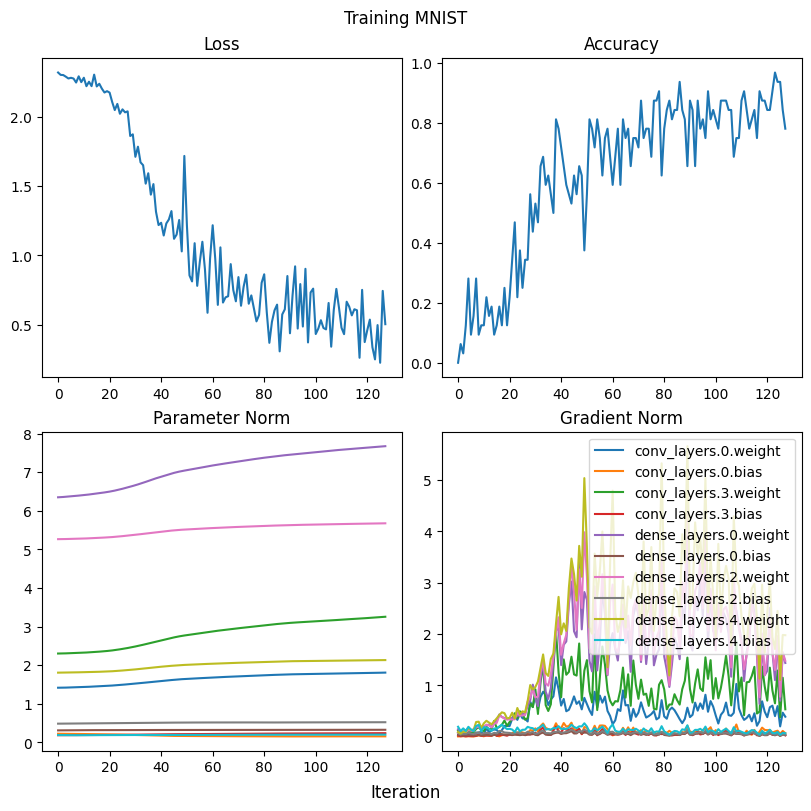

In [27]:
# For data generation
seed = 42
image_dim = (1, 28, 28)
output_dim = 10 # This is 10 for MNIST

# ============================================================
# TODO: Play around with different hyperparameters
# Training hyperparameters
num_iterations = 128
batch_size = 32

# Instantiate model
# You can use other activations such as Tanh, Sigmoid, GeLU, etc.
activation = "GeLU"

# Use LeNet
model = LeNet(
    image_dim[0],
    output_dim=output_dim,
)

# Instantiate optimizer, can use other optimizer such as Adam, RMSProp, etc.
lr = 1e-3
opt_constructor = torch.optim.Adam
# ============================================================

# Construct dataset
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(), 
    torchvision.transforms.Normalize((0.5,), (0.5,)),
])
dataset = torchvision.datasets.MNIST(
    "datasets",
    train=True,
    download=True,
    transform=transform,
)
model.to(device)
optimizer = opt_constructor(model.parameters(), lr)

train(dataset, model, optimizer, num_iterations, batch_size)

In [28]:
torch.save(
    model.state_dict(),
    "model.pt",
)

### Visualizing CNN
What's interesting about convolutional layers is the capability to capture spatial information.
Below what you should expect to see is that each filter captures specific features (e.g. edges, corners, shapes, etc.)

There are many newer visualization techniques, e.g. attributing specific features/pixels that result in particular predictions, see [this GradCAM repo](https://github.com/jacobgil/pytorch-grad-cam) for many examples.

In [29]:
state_dict = torch.load("model.pt", weights_only=True)
model.load_state_dict(state_dict)

<All keys matched successfully>

#### Visualizing CNN Filters

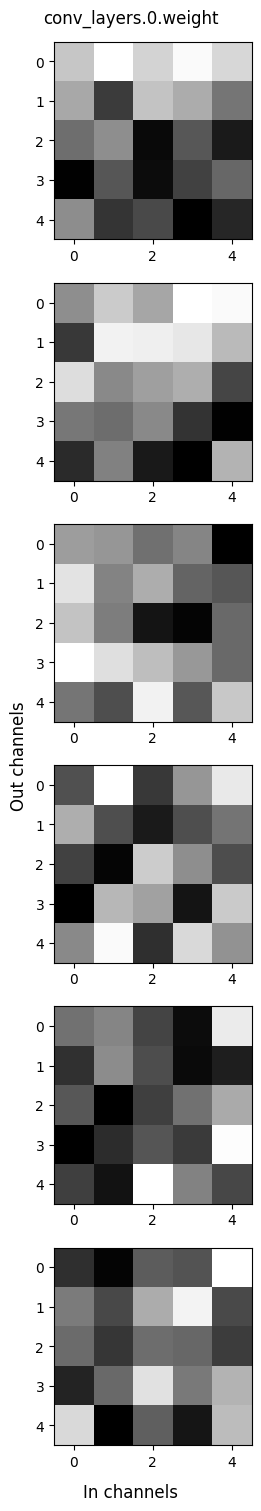

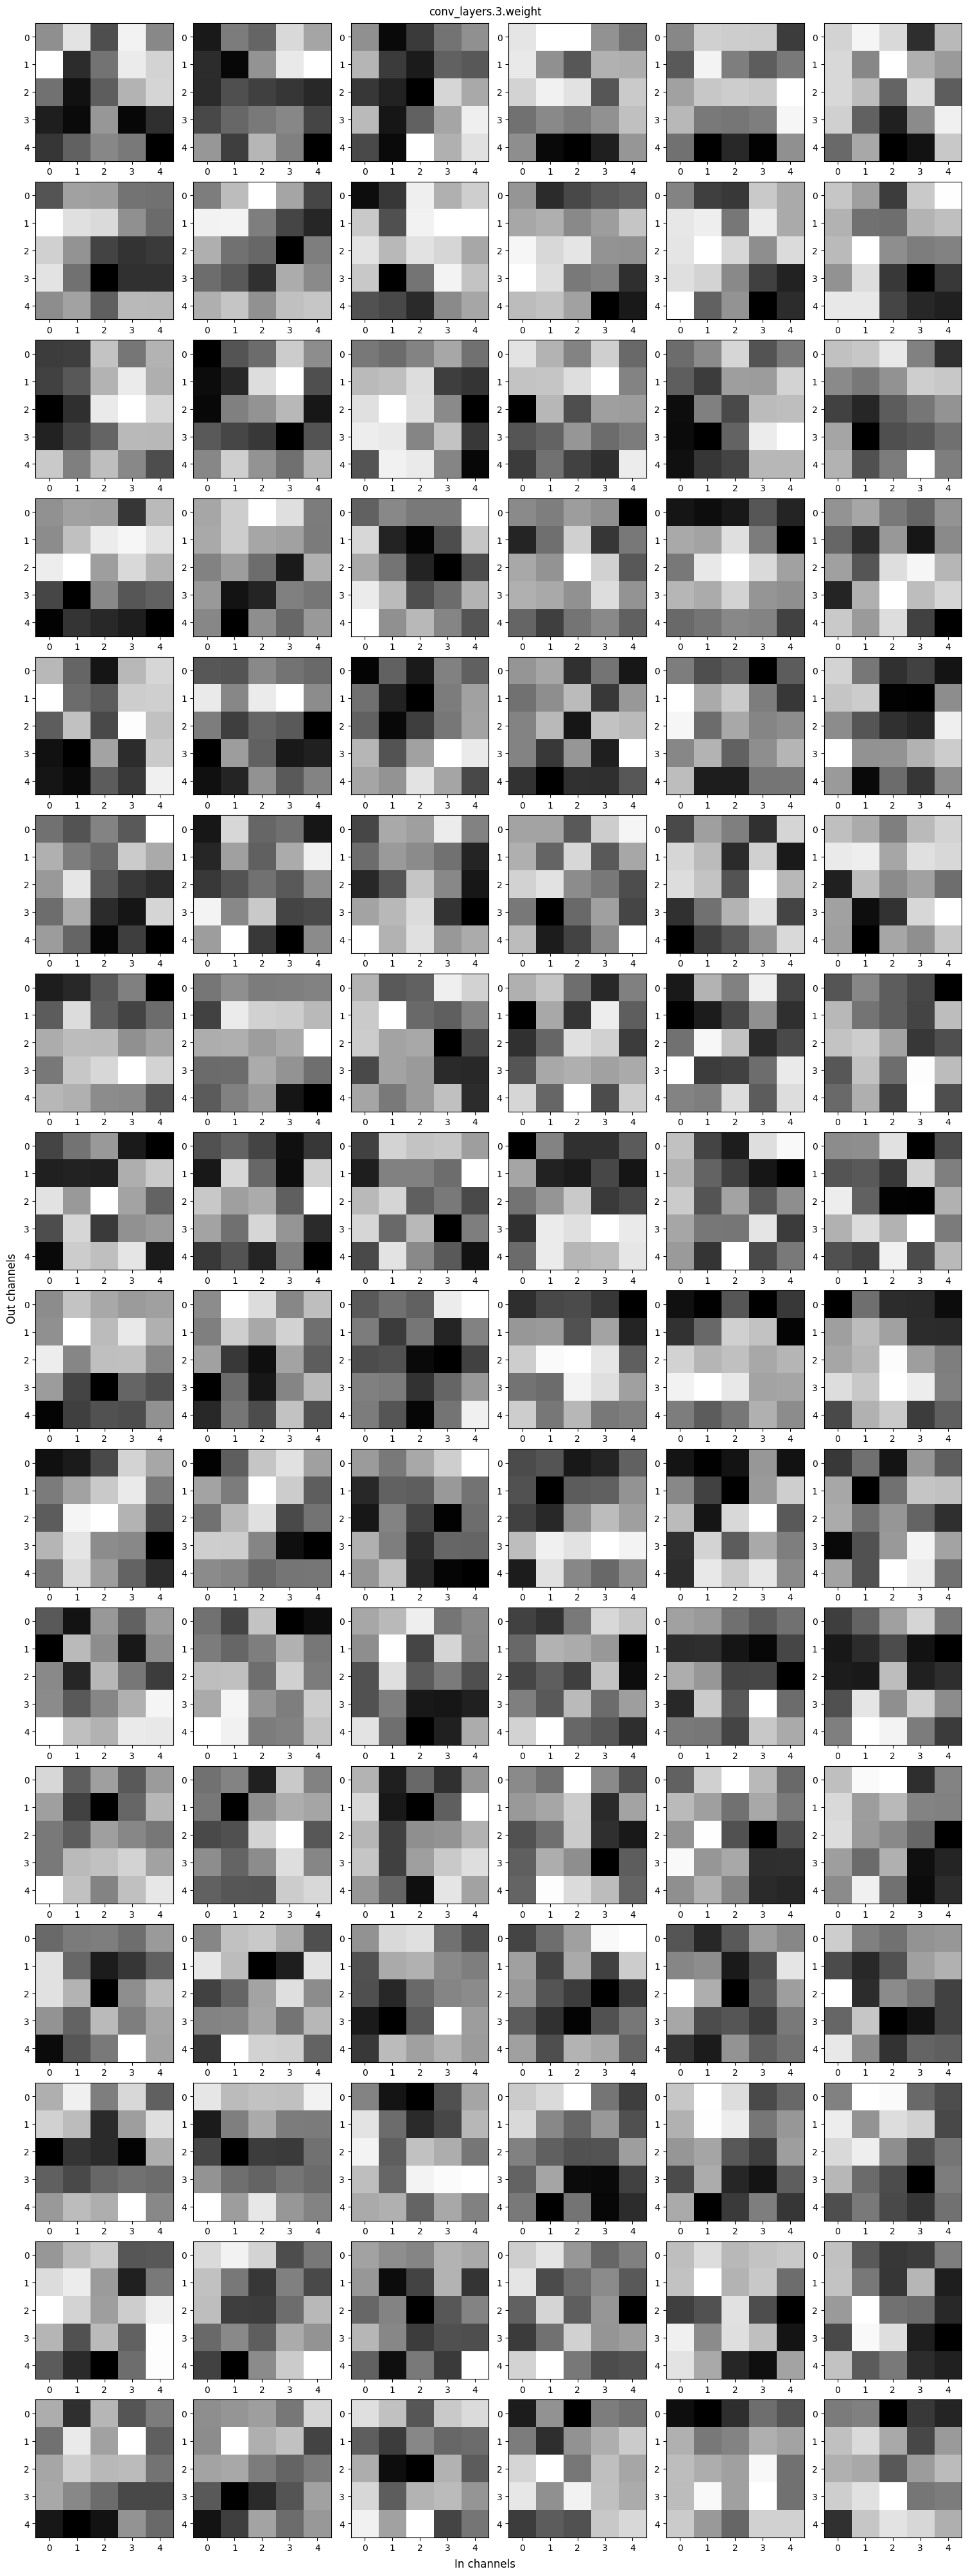

In [30]:
for k, p in model.named_parameters():
    if not k.startswith("conv_layers") or not k.endswith("weight"):
        continue

    # Normalize filter values to [0, 1] so we can visualize them
    f_min, f_max = p.min(), p.max()
    p = (p - f_min) / (f_max - f_min)

    fig, axes = plt.subplots(p.shape[0], p.shape[1], figsize=(2.5 * p.shape[1], 2.5 * p.shape[0]), layout="constrained")
    fig.suptitle(k)
    fig.supylabel("Out channels")
    fig.supxlabel("In channels")
    if axes.ndim == 1:
        axes = axes[:, None]

    for idx in np.ndindex(axes.shape):
        ax = axes[idx]
        curr_filter = p[idx]
        ax.imshow(curr_filter.detach().cpu().numpy(), cmap="gray")
    plt.show()

#### Visualizing Feature Maps Extracted based on Image

In [31]:
x, _ = dataset[0]

In [32]:
model.eval()
with torch.no_grad():
    filters = model(x[None], True)

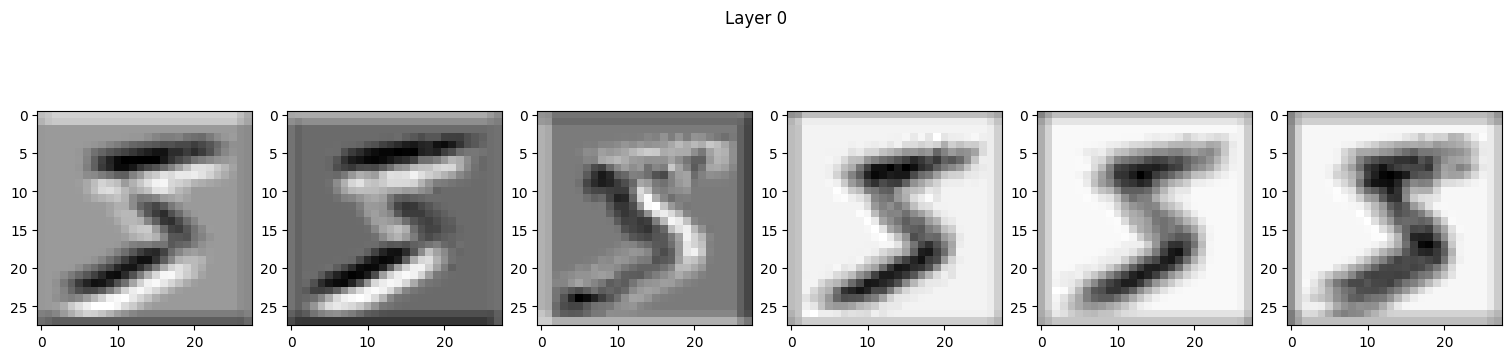

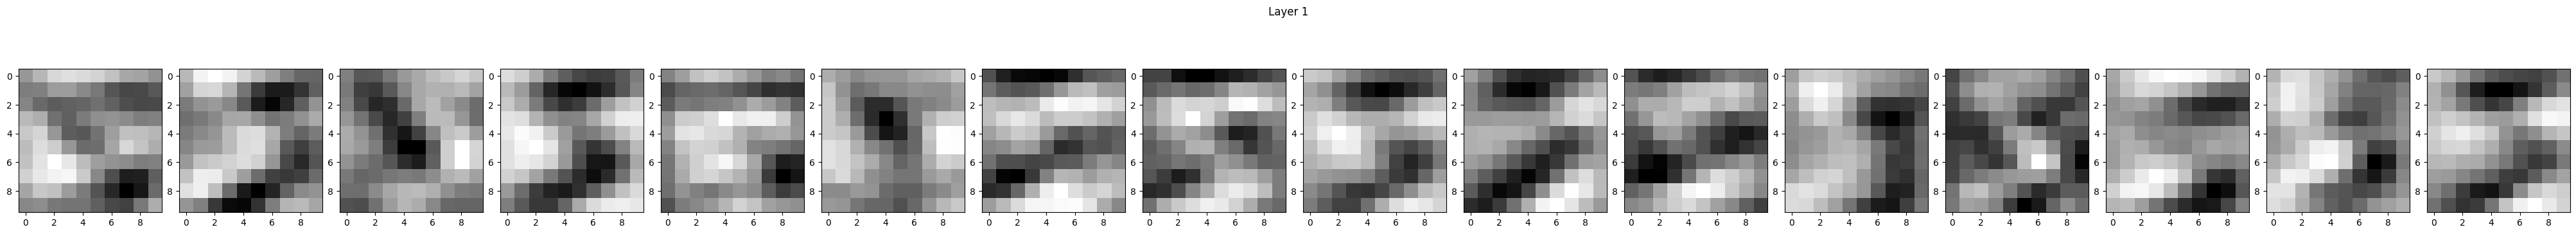

In [33]:
for layer_i, curr_filter in enumerate(filters):
    # Normalize filter values to [0, 1] so we can visualize them
    f_min, f_max = curr_filter.min(), curr_filter.max()
    curr_filter = (curr_filter - f_min) / (f_max - f_min)

    fig, axes = plt.subplots(1, curr_filter.shape[1], figsize=(2.5 * curr_filter.shape[1], 4), layout="constrained")
    fig.suptitle("Layer {}".format(layer_i))

    for idx in np.arange(len(axes)):
        ax = axes[idx]
        ax.imshow(curr_filter[0, idx].detach().cpu().numpy(), cmap="gray")
    plt.show()